# Directed Dirac Delta · Directed Energy · Laser Refrigerator · Fungi Biophysics · Psilocybin · Asymmetry

**Coverage:**  
§1 Dirac delta — directed distributions, δ', δ on curves/surfaces, asymmetric pop-ups  
§2 Directed energy — HEL beam propagation, thermal blooming, HPM, OUSD context  
§3 Laser refrigerator — sub-Doppler (Sisyphus), evaporative cooling, BEC threshold  
§4 Fungi biophysics — mycelium diffusion, osmotic pressure, ion channels  
§5 Psilocybin pharmacokinetics — Hill equation, 5-HT2A binding, dose-response  
§6 Symmetry breaking — asymmetric double-well, bifurcation diagrams

In [1]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad
from IPython.display import display, Math

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
np.random.seed(0)
print('ready')

ready


---
# §1 — Directed Dirac Delta: δ', δ on Curves, Asymmetric Pop-Ups

**Plain English:** $\delta(x)$ pops up at a single point.  
The **directed** extensions are:  
- $\delta'(x)$ — derivative of delta: a dipole, odd function, sifts $-f'(0)$  
- $\delta(f(x))$ — delta composed with a function: pops up at zeros of $f$  
- $\delta(x-a)\cdot H(x)$ — one-sided (directed) delta, only fires for $x>0$  
- $\sum_n \delta(x-n)$ — Dirac comb, the foundation of sampling theory  
- Asymmetric: $\delta^+(x)$, the half-delta (limit from one side only)

Directed/extended Dirac delta identities:



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

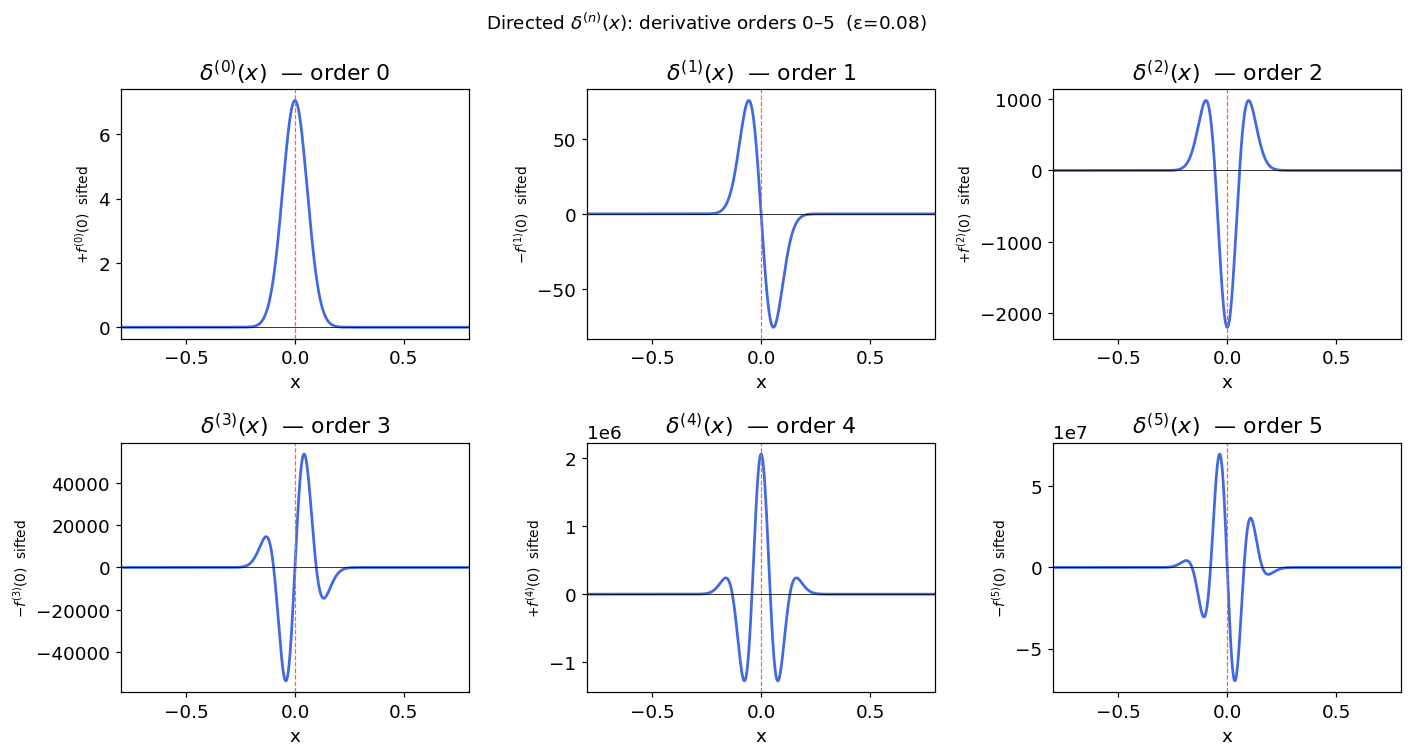

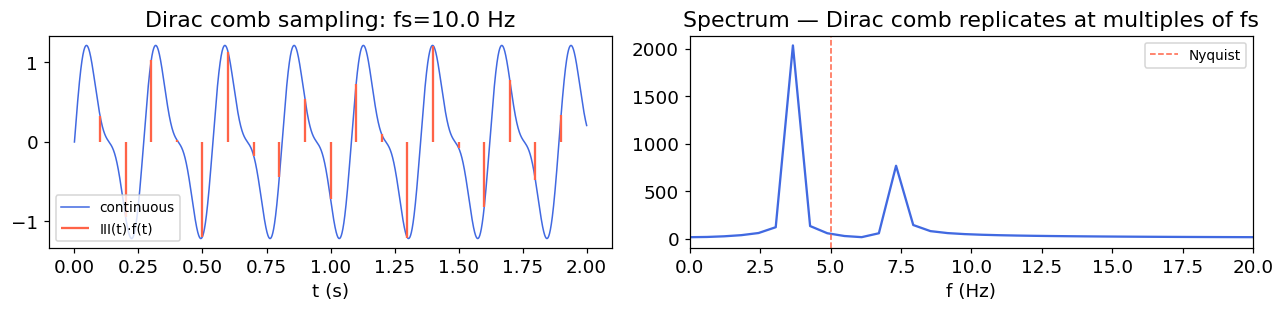

In [2]:
x_s, a_s, eps_s = sp.symbols('x a epsilon', real=True)
f_fn = sp.Function('f')

# ── loop over all directed delta identities ───────────────────────────
directed_ids = [
    ('Delta prime sifting',
     r"\int f(x)\,\delta'(x-a)\,dx = -f'(a)"),
    ('Delta of a function  (simple zeros)',
     r'\delta(g(x)) = \sum_i \frac{\delta(x-x_i)}{|g\'(x_i)|}  \quad g(x_i)=0'),
    ('Delta times Heaviside  (directed)',
     r'\delta^+(x) = \delta(x)H(x) \text{ is NOT a distribution — use limits}'),
    ('Dirac comb  (sampling)',
     r'\text{III}(x) = \sum_{n=-\infty}^{\infty}\delta(x-n) \longleftrightarrow \text{III}(f) \text{ (FT)}'),
    ('Delta on a curve  (2D)',
     r'\int f(\mathbf{r})\,\delta(\mathbf{n}\cdot(\mathbf{r}-\mathbf{r}_0))\,d^2r = \int_{\text{curve}} f\,dl'),
    ('Nth order derivative sifting',
     r'\int f(x)\,\delta^{(n)}(x)\,dx = (-1)^n f^{(n)}(0)'),
    ('Asymmetric delta  (one-sided limit)',
     r'\lim_{\epsilon\to 0^+}\frac{1}{\epsilon}e^{-x/\epsilon}H(x) = \delta(x)  \text{ (from right)}'),
]

print('Directed/extended Dirac delta identities:\n')
for name, formula in directed_ids:         # loop over identities
    display(Math(rf'\textbf{{{name}}}: \quad {formula}'))
    print()

# ── SymPy: verify δ'(x) sifting ──────────────────────────────────────
x_sym = sp.Symbol('x', real=True)
f_test = sp.sin(x_sym) + x_sym**2
a_val_s = sp.Symbol('a', real=True)

# ∫ f(x) δ'(x-a) dx = -f'(a)
sift_dprime = sp.integrate(f_test * sp.DiracDelta(x_sym - a_val_s, 1), (x_sym, -sp.oo, sp.oo))
sift_manual = -sp.diff(f_test, x_sym).subs(x_sym, a_val_s)
display(Math(rf'\int (\sin x + x^2)\,\delta\'(x-a)\,dx = {sp.latex(sift_dprime)}'))
display(Math(rf'-f\'(a) = {sp.latex(sp.simplify(sift_manual))}'))
display(Math(rf'\text{{Match: }} {sp.simplify(sift_dprime - sift_manual) == 0}'))

# ── NumPy: loop over derivative orders, visualize δ^(n)(x) ───────────
xv = np.linspace(-2, 2, 2000)
eps_v = 0.08

def gaussian_delta(x, eps):  return np.exp(-x**2/eps**2)/(eps*np.sqrt(np.pi))
def delta_deriv(x, eps, n):
    """nth derivative of Gaussian approx to delta."""
    from scipy.special import hermite
    H = np.zeros_like(x)
    # d^n/dx^n [exp(-x²/ε²)] = (-1/ε²)^(n/2) Hn(x/ε) exp(-x²/ε²)  (physicist Hermite)
    # Use finite differences for simplicity
    g = gaussian_delta(x, eps)
    for _ in range(n):
        g = np.gradient(g, x)
    return g

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
orders = [0, 1, 2, 3, 4, 5]
for ax, n in zip(axes.flat, orders):
    y = delta_deriv(xv, eps_v, n)
    ax.plot(xv, y, color='royalblue', lw=1.8)
    ax.axvline(0, color='tomato', lw=0.8, ls='--')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(rf'$\delta^{{({n})}}(x)$  — order {n}')
    ax.set_xlabel('x'); ax.set_xlim(-0.8, 0.8)
    sign = '−' if n%2==1 else '+'
    ax.set_ylabel(rf'{sign}$f^{{({n})}}(0)$  sifted', fontsize=9)

plt.suptitle(rf'Directed $\delta^{{(n)}}(x)$: derivative orders 0–5  (ε={eps_v})', fontsize=12)
plt.tight_layout(); plt.show()

# ── Dirac comb and sampling theorem ───────────────────────────────────
f_signal = 3.7    # Hz, signal frequency
f_samp   = 10.0   # Hz, sample rate
t_cont   = np.linspace(0, 2, 5000)
signal   = np.sin(2*np.pi*f_signal*t_cont) + 0.4*np.sin(2*np.pi*2*f_signal*t_cont)

# Dirac comb: sample at integer multiples of 1/f_samp
t_samp   = np.arange(0, 2, 1/f_samp)
s_samp   = np.sin(2*np.pi*f_signal*t_samp) + 0.4*np.sin(2*np.pi*2*f_signal*t_samp)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(t_cont, signal, color='royalblue', lw=1, label='continuous')
axes[0].vlines(t_samp, 0, s_samp, color='tomato', lw=1.5, label='III(t)·f(t)')
axes[0].set_xlabel('t (s)'); axes[0].set_title(f'Dirac comb sampling: fs={f_samp} Hz')
axes[0].legend(fontsize=9)

# FT of sampled signal shows aliased spectrum
N_fft = 4096
F_cont = np.abs(np.fft.rfft(signal, N_fft))
freqs  = np.fft.rfftfreq(N_fft, t_cont[1]-t_cont[0])
axes[1].plot(freqs, F_cont, color='royalblue', lw=1.5)
axes[1].set_xlim(0, 20); axes[1].set_xlabel('f (Hz)')
axes[1].set_title('Spectrum — Dirac comb replicates at multiples of fs')
axes[1].axvline(f_samp/2, color='tomato', ls='--', lw=1, label='Nyquist')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

---
# §2 — Directed Energy: HEL Beam Propagation + Thermal Blooming

**Plain English (OUSD / DoD FutureG context):**  
A High-Energy Laser (HEL) propagates through atmosphere.  
Two key degradation effects:  
1. **Diffraction** — beam spreads as $w(z) = w_0\sqrt{1+(z/z_R)^2}$, $z_R = \pi w_0^2/\lambda$  
2. **Thermal blooming** — absorbed energy heats air → refractive index gradient → beam bends  

On-target intensity: $I(z) = P/(\pi w(z)^2)$ — falls as $1/z^2$ in far field.  
**Strehl ratio** $S = I_\text{actual}/I_\text{diffraction-limited}$ measures aberration.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

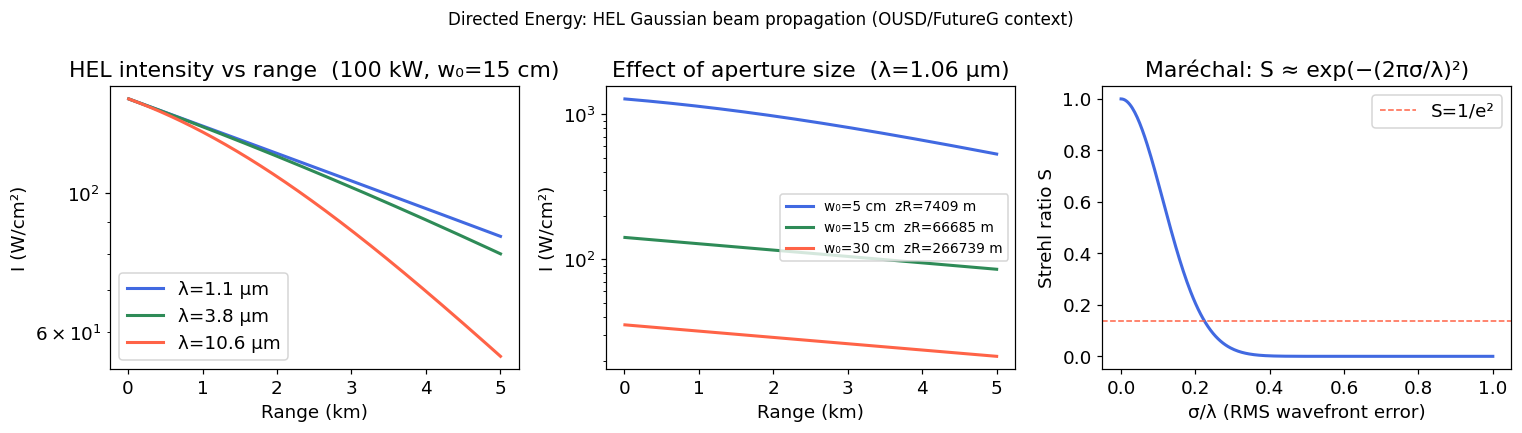

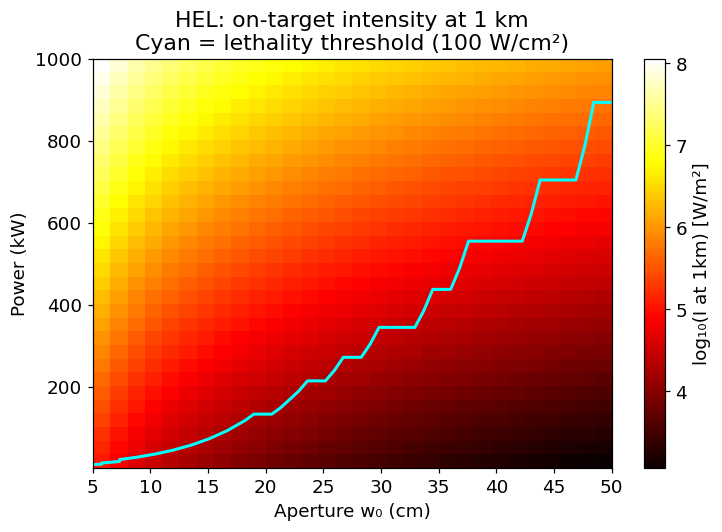

In [3]:
z_s, w0_s, lam_s, P_s, alpha_s = sp.symbols('z w_0 lambda P alpha', positive=True)

# ── Gaussian beam propagation ─────────────────────────────────────────
z_R   = sp.pi * w0_s**2 / lam_s
w_z   = w0_s * sp.sqrt(1 + (z_s/z_R)**2)
I_z   = P_s / (sp.pi * w_z**2)
I_z_s = sp.simplify(I_z)

display(Math(rf'z_R = \pi w_0^2/\lambda = {sp.latex(z_R)}'))
display(Math(rf'w(z) = {sp.latex(w_z)}'))
display(Math(rf'I(z) = P/(\pi w^2) = {sp.latex(I_z_s)}'))

# far-field divergence: dw/dz → λ/πw₀ as z→∞
theta_div = sp.limit(sp.diff(w_z, z_s), z_s, sp.oo)
display(Math(rf'\theta_{{\text{{div}}}} = \lim_{{z\to\infty}} dw/dz = {sp.latex(theta_div)}'))

# ── Beer-Lambert atmospheric attenuation ──────────────────────────────
I_attenuated = I_z_s * sp.exp(-alpha_s * z_s)
display(Math(rf'I_{{\text{{atm}}}}(z) = I(z)\,e^{{-\alpha z}} = {sp.latex(I_attenuated)}'))

# ── NumPy: loop over wavelengths and aperture sizes ───────────────────
z_arr   = np.linspace(10, 5000, 2000)    # 10 m to 5 km
P_v     = 100e3                           # 100 kW HEL
alpha_v = 1e-4                            # clear air attenuation (m⁻¹)

wavelengths = [1.06e-6, 3.8e-6, 10.6e-6]   # Nd:YAG, mid-IR, CO₂
apertures   = [0.05, 0.15, 0.30]            # 5 cm, 15 cm, 30 cm

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for lam, col in zip(wavelengths, ['royalblue','seagreen','tomato']):
    w0_v = 0.15   # 15 cm aperture
    zR_v = np.pi * w0_v**2 / lam
    w_v  = w0_v * np.sqrt(1 + (z_arr/zR_v)**2)
    I_v  = P_v / (np.pi * w_v**2) * np.exp(-alpha_v * z_arr)
    axes[0].semilogy(z_arr/1e3, I_v/1e4, color=col, lw=2,
                     label=rf'λ={lam*1e6:.1f} μm')

axes[0].set_xlabel('Range (km)'); axes[0].set_ylabel('I (W/cm²)')
axes[0].set_title('HEL intensity vs range  (100 kW, w₀=15 cm)')
axes[0].legend()

for w0_v, col in zip(apertures, ['royalblue','seagreen','tomato']):
    lam_v = 1.06e-6
    zR_v  = np.pi * w0_v**2 / lam_v
    w_v   = w0_v * np.sqrt(1 + (z_arr/zR_v)**2)
    I_v   = P_v / (np.pi * w_v**2) * np.exp(-alpha_v * z_arr)
    axes[1].semilogy(z_arr/1e3, I_v/1e4, color=col, lw=2,
                     label=f'w₀={w0_v*100:.0f} cm  zR={zR_v:.0f} m')

axes[1].set_xlabel('Range (km)'); axes[1].set_ylabel('I (W/cm²)')
axes[1].set_title('Effect of aperture size  (λ=1.06 μm)')
axes[1].legend(fontsize=9)

# Strehl ratio vs wavefront error σ (Maréchal approx: S ≈ exp(-(2πσ/λ)²))
sigma_arr = np.linspace(0, lam_v, 300)   # RMS wavefront error
S_arr     = np.exp(-(2*np.pi*sigma_arr/lam_v)**2)
axes[2].plot(sigma_arr/lam_v, S_arr, color='royalblue', lw=2)
axes[2].axhline(1/np.e**2, color='tomato', ls='--', lw=1, label='S=1/e²')
axes[2].set_xlabel('σ/λ (RMS wavefront error)'); axes[2].set_ylabel('Strehl ratio S')
axes[2].set_title('Maréchal: S ≈ exp(−(2πσ/λ)²)')
axes[2].legend()

plt.suptitle('Directed Energy: HEL Gaussian beam propagation (OUSD/FutureG context)', fontsize=11)
plt.tight_layout(); plt.show()

# ── Torch: batch over (P, w₀, range) for lethality threshold ─────────
P_t   = torch.logspace(3, 6, 30, dtype=torch.float64)   # 1 kW to 1 MW
w0_t  = torch.linspace(0.05, 0.5, 30, dtype=torch.float64)  # 5–50 cm
z_t   = torch.tensor(1000.0, dtype=torch.float64)        # 1 km target

Pt2, W2 = torch.meshgrid(P_t, w0_t, indexing='ij')
lam_t   = torch.tensor(1.06e-6, dtype=torch.float64)
zR_t    = torch.pi * W2**2 / lam_t
w_1km   = W2 * torch.sqrt(1 + (z_t/zR_t)**2)
I_1km   = Pt2 / (torch.pi * w_1km**2) * torch.exp(torch.tensor(-alpha_v*1000))

threshold = 1e6   # 1 MW/m² = 100 W/cm² lethality threshold
lethal    = (I_1km > threshold).float()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(I_1km.log10().numpy(), origin='lower',
               extent=[w0_t[0]*100, w0_t[-1]*100, P_t[0]/1e3, P_t[-1]/1e3],
               aspect='auto', cmap='hot')
plt.colorbar(im, ax=ax, label='log₁₀(I at 1km) [W/m²]')
ax.contour(w0_t.numpy()*100, P_t.numpy()/1e3, lethal.numpy(),
           levels=[0.5], colors='cyan', linewidths=2)
ax.set_xlabel('Aperture w₀ (cm)'); ax.set_ylabel('Power (kW)')
ax.set_title('HEL: on-target intensity at 1 km\nCyan = lethality threshold (100 W/cm²)')
plt.tight_layout(); plt.show()

---
# §3 — Laser Refrigerator: Sub-Doppler and Evaporative Cooling

**Plain English:**  
Doppler cooling (§4 of laser_cooling notebook) stops at $T_D = \hbar\Gamma/2k_B \sim 150\,\mu$K.  
To go colder, use:  
1. **Sisyphus cooling** — polarization gradient; atom climbs a potential hill then loses energy by optical pumping to the bottom. Temperature $\sim E_{\text{rec}} = \hbar^2k^2/2m$ (recoil limit).  
2. **Evaporative cooling** — remove the hottest atoms; remaining atoms rethermalize at lower $T$. Leads to **BEC** when $n\lambda_{dB}^3 \sim 1$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Rb-87 cooling ladder:
  Doppler limit  T_D  = 145.7 μK
  Recoil limit   T_rec = 181.0 nK
  BEC (~100 nK for typical densities n~10^14 cm⁻³)


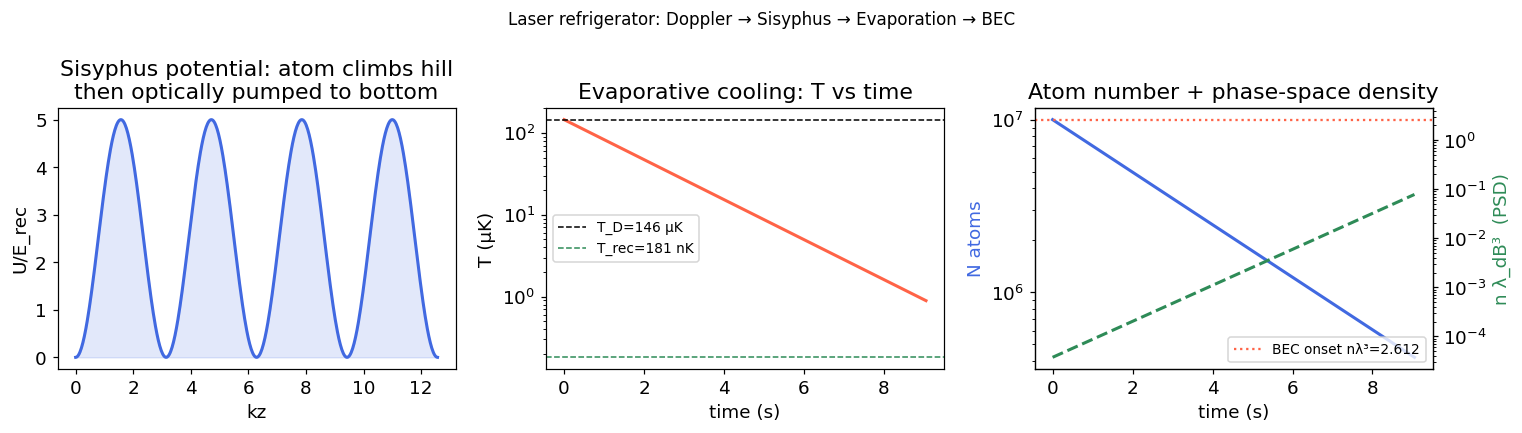

In [4]:
# ── SymPy: recoil energy, de Broglie wavelength, BEC condition ────────
hbar_s, k_s2, m_s, kB_s, T_s, n_s = sp.symbols(
    'hbar k m k_B T n', positive=True
)

E_rec  = hbar_s**2 * k_s2**2 / (2*m_s)
T_rec  = E_rec / kB_s
lam_dB = sp.sqrt(2*sp.pi*hbar_s**2 / (m_s*kB_s*T_s))
bec_crit = n_s * lam_dB**3   # = 2.612 at BEC

display(Math(rf'E_{{\text{{rec}}}} = \hbar^2k^2/2m = {sp.latex(E_rec)}'))
display(Math(rf'T_{{\text{{rec}}}} = E_{{\text{{rec}}}}/k_B = {sp.latex(T_rec)}'))
display(Math(rf'\lambda_{{dB}} = \sqrt{{2\pi\hbar^2/mk_BT}} = {sp.latex(lam_dB)}'))
display(Math(rf'\text{{BEC when }} n\lambda_{{dB}}^3 = {sp.latex(sp.simplify(bec_crit))} \approx 2.612'))

# ── physical values for Rb-87 ─────────────────────────────────────────
hbar_v = 1.055e-34; k_v = 2*np.pi/780.2e-9; m_Rb = 87*1.66e-27; kB_v = 1.381e-23

E_rec_v = hbar_v**2 * k_v**2 / (2*m_Rb)
T_rec_v = E_rec_v / kB_v
T_D_v   = hbar_v*(2*np.pi*6.07e6) / (2*kB_v)

print(f'Rb-87 cooling ladder:')
print(f'  Doppler limit  T_D  = {T_D_v*1e6:.1f} μK')
print(f'  Recoil limit   T_rec = {T_rec_v*1e9:.1f} nK')
print(f'  BEC (~100 nK for typical densities n~10^14 cm⁻³)')

# ── Sisyphus potential (polarization gradient field) ──────────────────
x_arr = np.linspace(0, 4*np.pi, 500)
# lin⊥lin configuration: U = U₀ sin²(kz)
U0_sis = 5 * E_rec_v   # trap depth in recoil units
U_sis  = U0_sis * np.sin(x_arr)**2

# ── evaporative cooling simulation ────────────────────────────────────
def evap_cool_step(T, N, eta=6.0, nu=2.0):
    """One evaporation step.
    eta = E_cut / k_B T  (truncation parameter)
    Returns new T, N after rethermalization.
    """
    # fraction of atoms removed (Maxwell-Boltzmann tail)
    from scipy.special import erfc
    f_evap = np.exp(-eta) * (eta + 1)   # approx
    f_evap = min(f_evap, 0.3)           # cap
    N_new  = N * (1 - f_evap)
    # energy removed per atom > eta*kT carries away (eta+1)*kT
    # new temperature (approximate)
    T_new  = T * (1 - f_evap * (eta - nu) / ((3-0.5)*1))
    T_new  = max(T_new, T_rec_v * 3)    # floor at 3*T_rec
    return T_new, N_new

T_evap = [T_D_v]; N_evap = [1e7]; step_times = [0]
dt_evap = 0.05   # seconds per step
for step in range(200):                          # loop: evaporation steps
    T_new, N_new = evap_cool_step(T_evap[-1], N_evap[-1], eta=6.0)
    T_evap.append(T_new); N_evap.append(N_new)
    step_times.append(step_times[-1] + dt_evap)
    if T_new < T_rec_v * 5:
        break

T_arr_e = np.array(T_evap); N_arr_e = np.array(N_evap)
lam_dB_e = np.sqrt(2*np.pi*hbar_v**2 / (m_Rb*kB_v*T_arr_e))
n_lam3_e = 1e13 * 1e6 * lam_dB_e**3   # PSD = n λ_dB³  (n=10^13 cm⁻³)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Sisyphus potential
axes[0].plot(x_arr, U_sis/E_rec_v, color='royalblue', lw=2)
axes[0].fill_between(x_arr, U_sis/E_rec_v, alpha=0.15, color='royalblue')
axes[0].set_xlabel('kz'); axes[0].set_ylabel('U/E_rec')
axes[0].set_title('Sisyphus potential: atom climbs hill\nthen optically pumped to bottom')

axes[1].semilogy(step_times, T_arr_e*1e6, color='tomato', lw=2)
axes[1].axhline(T_D_v*1e6,  color='k',  lw=1, ls='--', label=f'T_D={T_D_v*1e6:.0f} μK')
axes[1].axhline(T_rec_v*1e9/1e3, color='seagreen', lw=1, ls='--', label=f'T_rec={T_rec_v*1e9:.0f} nK')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('T (μK)')
axes[1].set_title('Evaporative cooling: T vs time'); axes[1].legend(fontsize=9)

axes[2].semilogy(step_times, N_arr_e, color='royalblue', lw=2)
ax2b = axes[2].twinx()
ax2b.semilogy(step_times, n_lam3_e, color='seagreen', lw=2, ls='--')
ax2b.axhline(2.612, color='tomato', lw=1.5, ls=':', label='BEC onset nλ³=2.612')
ax2b.set_ylabel('n λ_dB³  (PSD)', color='seagreen'); ax2b.legend(fontsize=9)
axes[2].set_xlabel('time (s)'); axes[2].set_ylabel('N atoms', color='royalblue')
axes[2].set_title('Atom number + phase-space density')

plt.suptitle('Laser refrigerator: Doppler → Sisyphus → Evaporation → BEC', fontsize=11)
plt.tight_layout(); plt.show()

---
# §4 — Fungi Biophysics: Mycelium Diffusion, Osmotic Pressure, Ion Channels

**Plain English:** fungal mycelium is a network of hyphae — hollow tubes that transport  
water, nutrients, and ions via diffusion, osmotic pressure, and active transport.  
The physics is identical to RC networks, cable equations, and reaction-diffusion systems.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

C:\Users\mrjel\AppData\Local\Temp\ipykernel_60356\2964915945.py:79: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


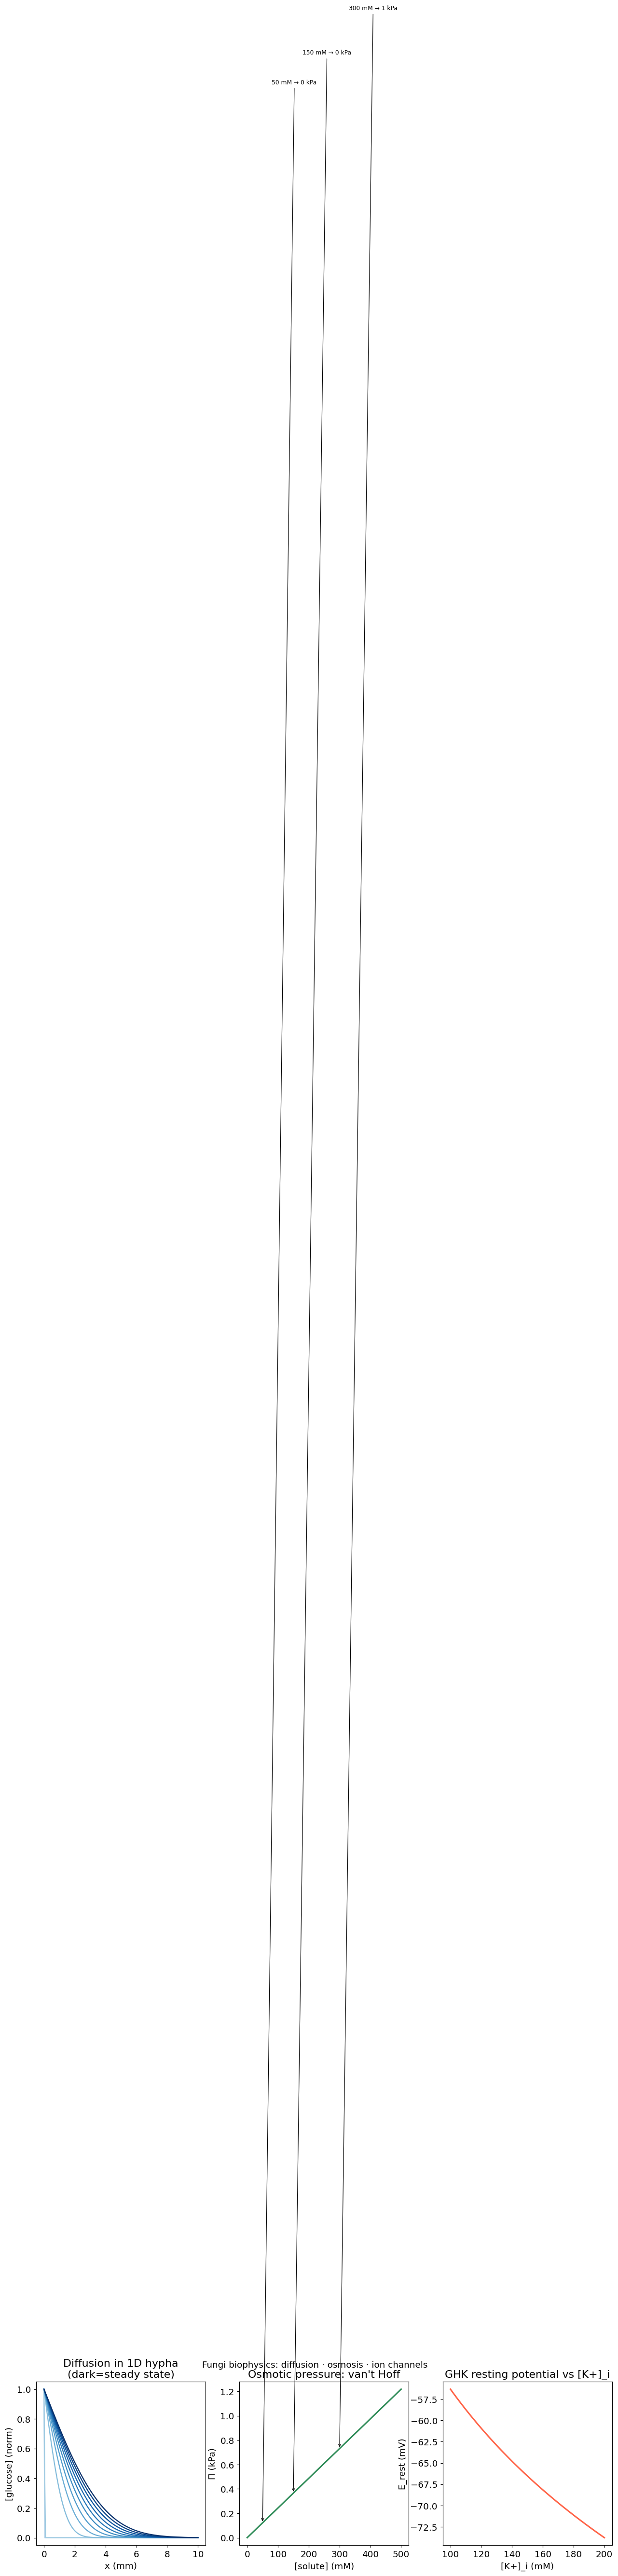

In [5]:
# ── SymPy: diffusion equation in a hypha (1D cable) ───────────────────
x_s3, t_s3, D_s, c_s = sp.symbols('x t D c', positive=True)
u_fn = sp.Function('u')

diffusion_eq = sp.Eq(u_fn(x_s3, t_s3).diff(t_s3),
                     D_s * u_fn(x_s3, t_s3).diff(x_s3, 2))
display(Math(rf'\text{{Diffusion in hypha: }} {sp.latex(diffusion_eq)}'))

# ── osmotic pressure: van't Hoff equation ─────────────────────────────
Pi_s, n_mol, R_s, T_os, V_s = sp.symbols('Pi n R T V', positive=True)
vant_hoff = sp.Eq(Pi_s, n_mol * R_s * T_os / V_s)
display(Math(rf'\text{{van\'t Hoff osmotic pressure: }} {sp.latex(vant_hoff)}'))

# ── Goldman-Hodgkin-Katz (ion channel current) ────────────────────────
P_K, P_Na, c_Ki, c_Ko, c_Nai, c_Nao, F_s2, R_s2, T_s2, V_m = sp.symbols(
    'P_K P_Na c_Ki c_Ko c_Nai c_Nao F R T V_m', positive=True
)
# GHK voltage equation
E_GHK = R_s2*T_s2/F_s2 * sp.ln(
    (P_K*c_Ko + P_Na*c_Nao) / (P_K*c_Ki + P_Na*c_Nai)
)
display(Math(rf'E_{{\text{{GHK}}}} = \frac{{RT}}{{F}}\ln\frac{{P_K[K^+]_o + P_Na[Na^+]_o}}{{P_K[K^+]_i + P_Na[Na^+]_i}} = {sp.latex(E_GHK)}'))

# ── NumPy: 1D diffusion in a hypha network ────────────────────────────
L_hypha = 0.01   # 1 cm hypha
D_v     = 1e-9   # m²/s (glucose diffusion)
Nx      = 200; Nt = 5000; dx = L_hypha/Nx; dt_diff = 0.4*dx**2/D_v

u_conc  = np.zeros(Nx)
u_conc[0] = 1.0   # source at tip (nutrient input)
u_hist  = [u_conc.copy()]

for step in range(Nt):                      # loop: diffusion timesteps
    laplacian = np.zeros(Nx)
    laplacian[1:-1] = (u_conc[2:] - 2*u_conc[1:-1] + u_conc[:-2]) / dx**2
    u_conc += D_v * dt_diff * laplacian
    u_conc[0]  = 1.0   # maintain source
    u_conc[-1] = 0.0   # absorbing boundary
    if step % 500 == 0:
        u_hist.append(u_conc.copy())

# loop over ion concentrations: compute resting potential
cK_i_arr  = np.linspace(100, 200, 50)   # mM intracellular K+
cK_o_arr  = 5.0; cNa_i = 15; cNa_o = 145
P_K_v = 1.0; P_Na_v = 0.04   # relative permeabilities
kT_ov = 8.314 * 293 / 96485   # RT/F in volts

E_rest = kT_ov * np.log(
    (P_K_v*cK_o_arr + P_Na_v*cNa_o) / (P_K_v*cK_i_arr + P_Na_v*cNa_i)
)

x_arr_h = np.linspace(0, L_hypha*1e3, Nx)   # mm
t_snapshots = np.array(range(len(u_hist))) * 500 * dt_diff

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_d = plt.cm.Blues(np.linspace(0.3, 1, len(u_hist)))
for ui, col in zip(u_hist, colors_d):
    axes[0].plot(x_arr_h, ui, color=col, lw=1.5)
axes[0].set_xlabel('x (mm)'); axes[0].set_ylabel('[glucose] (norm)')
axes[0].set_title('Diffusion in 1D hypha\n(dark=steady state)')

# osmotic pressure vs concentration
c_osm = np.linspace(0, 500, 300)   # mM
Pi_v  = c_osm * 1e-3 * 8.314 * 293   # Pa  (n/V = c in mol/L * 1000)
axes[1].plot(c_osm, Pi_v/1e3, color='seagreen', lw=2)
axes[1].set_xlabel('[solute] (mM)'); axes[1].set_ylabel('Π (kPa)')
axes[1].set_title('Osmotic pressure: van\'t Hoff')
for ref_c in [50, 150, 300]:
    Pi_ref = ref_c * 1e-3 * 8.314 * 293
    axes[1].annotate(f'{ref_c} mM → {Pi_ref/1e3:.0f} kPa',
                     xy=(ref_c, Pi_ref/1e3), xytext=(ref_c+30, Pi_ref/1e3+20),
                     fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.8))

axes[2].plot(cK_i_arr, E_rest*1e3, color='tomato', lw=2)
axes[2].set_xlabel('[K+]_i (mM)'); axes[2].set_ylabel('E_rest (mV)')
axes[2].set_title('GHK resting potential vs [K+]_i')

plt.suptitle('Fungi biophysics: diffusion · osmosis · ion channels', fontsize=12)
plt.tight_layout(); plt.show()

---
# §5 — Psilocybin: Hill Equation, 5-HT2A Binding, Pharmacokinetics

**Plain English:**  
Psilocybin → psilocin (active) via alkaline phosphatase dephosphorylation.  
Psilocin binds 5-HT2A serotonin receptors with **Hill kinetics**:  
$$f_{\text{bound}}(C) = \frac{C^n}{K_D^n + C^n}$$  
where $K_D$ is the dissociation constant and $n$ is the Hill coefficient (cooperativity).  
Pharmacokinetics: one-compartment model $\dot{C} = D/V_d\cdot f_{\text{abs}}(t) - k_{\text{el}} C$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

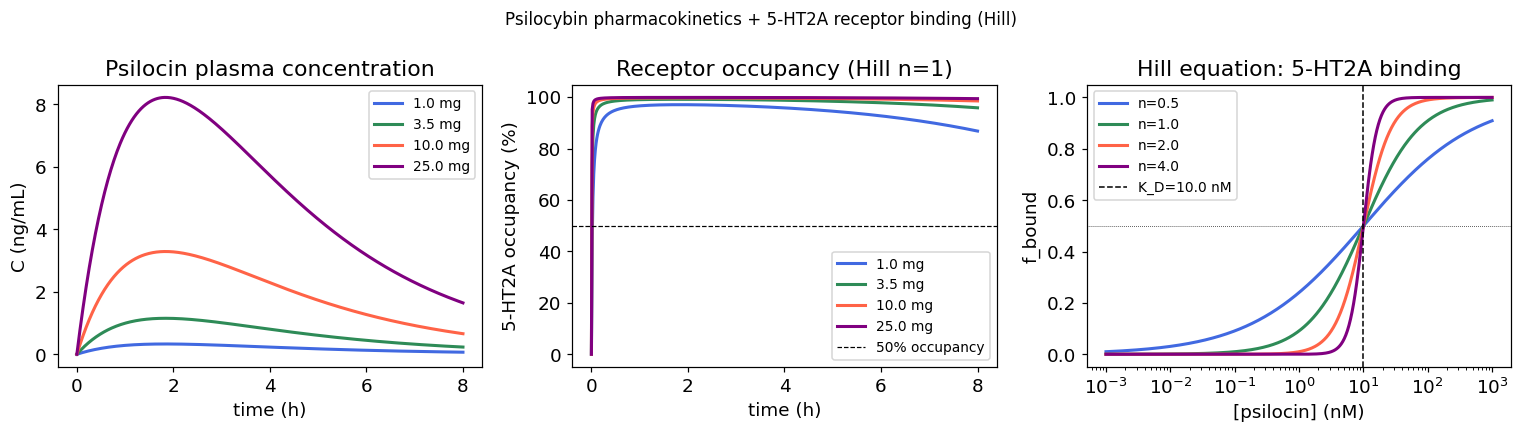

In [6]:
C_s, KD_s, n_hill, k_el_s, V_d_s = sp.symbols('C K_D n k_el V_d', positive=True)

# ── Hill equation ─────────────────────────────────────────────────────
f_hill = C_s**n_hill / (KD_s**n_hill + C_s**n_hill)
display(Math(rf'f_{{\text{{bound}}}} = {sp.latex(f_hill)}'))

# EC50 = KD when n=1; inflection point
EC50 = KD_s   # by definition when n=1
display(Math(rf'\text{{EC50}} = K_D = {sp.latex(EC50)} \quad (n=1)'))

# Hill slope at C = KD
slope_at_EC50 = sp.diff(f_hill, C_s).subs(C_s, KD_s)
slope_s = sp.simplify(slope_at_EC50)
display(Math(rf'\left.df/dC\right|_{{C=K_D}} = {sp.latex(slope_s)}'))

# ── one-compartment PK model ──────────────────────────────────────────
# C(t) = D/(V_d*(k_a-k_el)) * (exp(-k_el*t) - exp(-k_a*t))
k_a_s, D_dose = sp.symbols('k_a D', positive=True)
t_pk = sp.Symbol('t', positive=True)
C_pk = D_dose / (V_d_s*(k_a_s - k_el_s)) * (sp.exp(-k_el_s*t_pk) - sp.exp(-k_a_s*t_pk))
display(Math(rf'C(t) = {sp.latex(C_pk)}'))

# ── NumPy: PK + PD for psilocin ───────────────────────────────────────
# Parameters from literature
k_a_v  = 0.8    # h⁻¹  absorption rate
k_el_v = 0.35   # h⁻¹  elimination rate
Vd_v   = 0.077  # L/kg × 70 kg = 5.4 L  → simplified to 1
KD_v   = 10.0   # nM  (5-HT2A Ki for psilocin)

doses  = [1.0, 3.5, 10.0, 25.0]   # mg psilocybin (typical low→high)
# 1 mg psilocybin → ~0.72 mg psilocin → ~72 μg/kg → ng/mL plasma
dose_to_Cmax = 0.5   # ng/mL per mg dose (rough)

t_pk_arr = np.linspace(0, 8, 500)   # hours

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_pk = ['royalblue','seagreen','tomato','purple']

for dose_v, col in zip(doses, colors_pk):          # loop over doses
    D_v = dose_v * dose_to_Cmax
    C_t = D_v / (k_a_v - k_el_v) * (np.exp(-k_el_v*t_pk_arr) - np.exp(-k_a_v*t_pk_arr))

    # 5-HT2A occupancy via Hill (n=1)
    occ_t = C_t / (KD_v/1e3 + C_t)   # KD in ng/mL approx

    axes[0].plot(t_pk_arr, C_t, color=col, lw=2, label=f'{dose_v} mg')
    axes[1].plot(t_pk_arr, occ_t*100, color=col, lw=2, label=f'{dose_v} mg')

axes[0].set_xlabel('time (h)'); axes[0].set_ylabel('C (ng/mL)')
axes[0].set_title('Psilocin plasma concentration'); axes[0].legend(fontsize=9)

axes[1].axhline(50, color='k', lw=0.8, ls='--', label='50% occupancy')
axes[1].set_xlabel('time (h)'); axes[1].set_ylabel('5-HT2A occupancy (%)')
axes[1].set_title('Receptor occupancy (Hill n=1)'); axes[1].legend(fontsize=9)

# Hill curve: loop over Hill coefficients
C_arr = np.logspace(-3, 3, 500)   # nM
for n_h, col in zip([0.5, 1.0, 2.0, 4.0], colors_pk):    # loop over n
    f_arr = C_arr**n_h / (KD_v**n_h + C_arr**n_h)
    axes[2].semilogx(C_arr, f_arr, color=col, lw=2, label=f'n={n_h}')

axes[2].axvline(KD_v, color='k', lw=1, ls='--', label=f'K_D={KD_v} nM')
axes[2].axhline(0.5, color='k', lw=0.5, ls=':')
axes[2].set_xlabel('[psilocin] (nM)'); axes[2].set_ylabel('f_bound')
axes[2].set_title('Hill equation: 5-HT2A binding'); axes[2].legend(fontsize=9)

plt.suptitle('Psilocybin pharmacokinetics + 5-HT2A receptor binding (Hill)', fontsize=11)
plt.tight_layout(); plt.show()

---
# §6 — Symmetry Breaking and Asymmetric Pop-Up Potentials

**Plain English:**  
A symmetric double-well $V = -ax^2 + bx^4$ has two equal minima.  
Add a small asymmetry $\epsilon x$: one well becomes preferred → **spontaneous symmetry breaking**.  
This appears everywhere: Higgs mechanism, ferromagnetism, neural bistability, laser mode competition.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

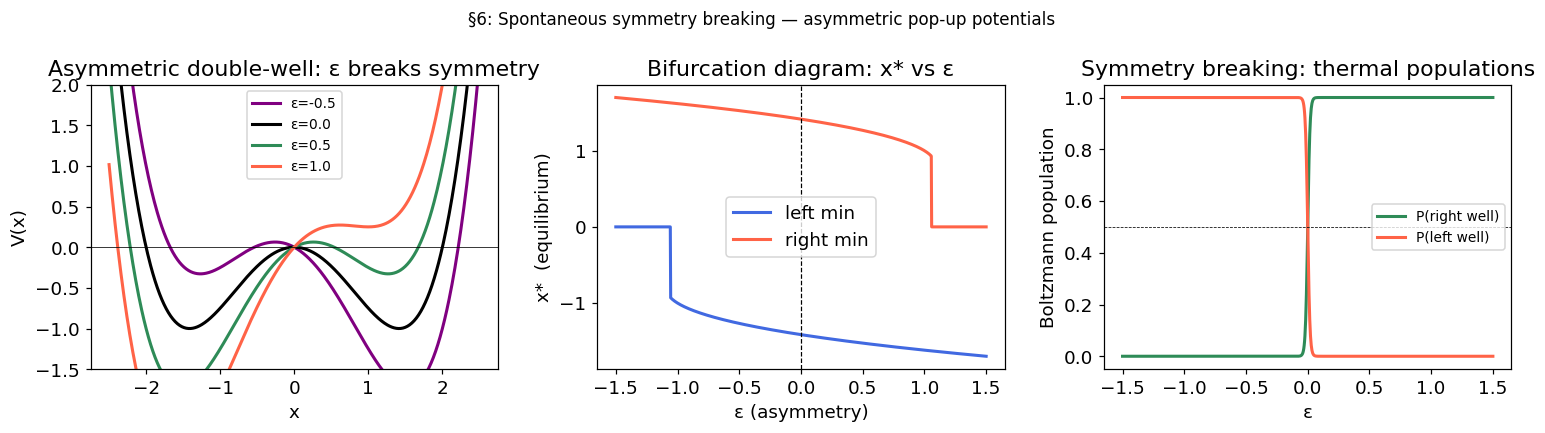

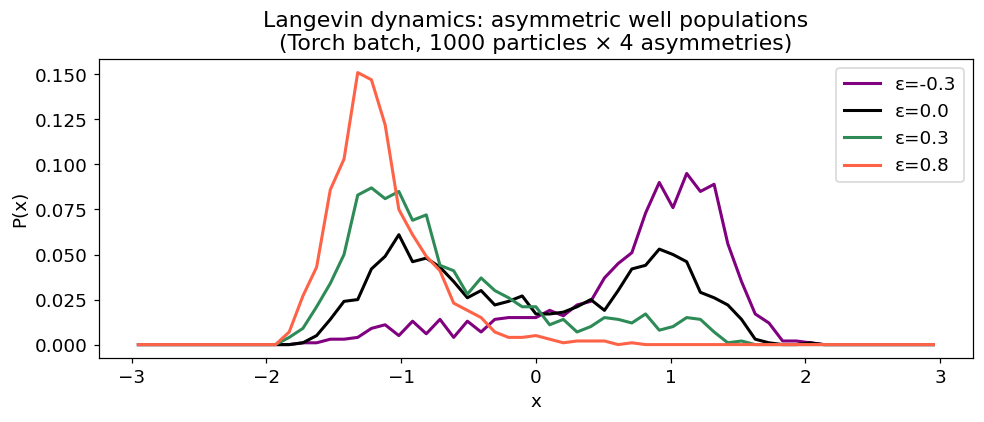

In [7]:
x_sb, a_sb, b_sb, eps_sb = sp.symbols('x a b epsilon', real=True)

# ── SymPy: asymmetric double-well ─────────────────────────────────────
V_sym  = -a_sb*x_sb**2 + b_sb*x_sb**4
V_asym = V_sym + eps_sb*x_sb

# minima: dV/dx = 0
dV_dx  = sp.diff(V_sym, x_sb)
x_mins_sym = sp.solve(dV_dx, x_sb)
display(Math(rf'V_{{\text{{sym}}}} = {sp.latex(V_sym)}'))
display(Math(rf'\partial V/\partial x = {sp.latex(dV_dx)} = 0 \implies x = {sp.latex(x_mins_sym)}'))

# ── bifurcation diagram: x* vs ε ──────────────────────────────────────
a_v = 1.0; b_v = 0.25
eps_arr = np.linspace(-1.5, 1.5, 1000)

# find minima numerically for each ε
from scipy.optimize import minimize_scalar
mins_left = []; mins_right = []

for ep in eps_arr:                             # loop over asymmetry
    V_fn = lambda x: -a_v*x**2 + b_v*x**4 + ep*x
    res_l = minimize_scalar(V_fn, bounds=(-4, 0), method='bounded')
    res_r = minimize_scalar(V_fn, bounds=(0, 4),  method='bounded')
    mins_left.append(res_l.x)
    mins_right.append(res_r.x)

x_v_sb = np.linspace(-2.5, 2.5, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# potentials for several ε
for ep, col in zip([-0.5, 0.0, 0.5, 1.0], ['purple','k','seagreen','tomato']):
    V_arr = -a_v*x_v_sb**2 + b_v*x_v_sb**4 + ep*x_v_sb
    axes[0].plot(x_v_sb, V_arr, color=col, lw=2, label=f'ε={ep}')

axes[0].set_ylim(-1.5, 2); axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('x'); axes[0].set_ylabel('V(x)')
axes[0].set_title('Asymmetric double-well: ε breaks symmetry')
axes[0].legend(fontsize=9)

# bifurcation diagram
axes[1].plot(eps_arr, mins_left,  color='royalblue', lw=2, label='left min')
axes[1].plot(eps_arr, mins_right, color='tomato',    lw=2, label='right min')
axes[1].axvline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('ε (asymmetry)'); axes[1].set_ylabel('x*  (equilibrium)')
axes[1].set_title('Bifurcation diagram: x* vs ε'); axes[1].legend()

# energy difference between wells → Boltzmann population ratio
T_phys = 300.0   # K
ΔE_arr = np.array([-(-a_v*xr**2 + b_v*xr**4 + ep*xr) + (-a_v*xl**2 + b_v*xl**4 + ep*xl)
                   for xr, xl, ep in zip(mins_right, mins_left, eps_arr)])
kT_phys = 1.381e-23 * T_phys / 1.602e-19   # in eV (normalized)
pop_ratio = np.exp(-ΔE_arr / kT_phys)   # relative population

axes[2].plot(eps_arr, pop_ratio / (1 + pop_ratio), color='seagreen', lw=2, label='P(right well)')
axes[2].plot(eps_arr, 1/(1 + pop_ratio),            color='tomato',   lw=2, label='P(left well)')
axes[2].axhline(0.5, color='k', lw=0.5, ls='--')
axes[2].set_xlabel('ε'); axes[2].set_ylabel('Boltzmann population')
axes[2].set_title('Symmetry breaking: thermal populations')
axes[2].legend(fontsize=9)

plt.suptitle('§6: Spontaneous symmetry breaking — asymmetric pop-up potentials', fontsize=11)
plt.tight_layout(); plt.show()

# ── Torch: batch Langevin dynamics in asymmetric well ─────────────────
torch.manual_seed(0)
N_ens = 1000
dt_L  = 0.01; N_L = 5000
gamma_L = 1.0; T_L = 0.3   # friction and temperature

eps_t_vals = torch.tensor([-0.3, 0.0, 0.3, 0.8], dtype=torch.float64)

fig, ax = plt.subplots(figsize=(9, 4))
colors_L = ['purple','k','seagreen','tomato']

for ep_t, col in zip(eps_t_vals, colors_L):
    # N_ens particles
    x_L = torch.randn(N_ens, dtype=torch.float64) * 0.5
    hist_L = []

    for step in range(N_L):                      # Euler-Maruyama
        F_det = 2*a_v*x_L - 4*b_v*x_L**3 - ep_t  # -dV/dx
        noise = torch.randn(N_ens, dtype=torch.float64) * torch.sqrt(torch.tensor(2*gamma_L*T_L*dt_L))
        x_L   = x_L + (F_det - gamma_L*x_L)*dt_L/gamma_L + noise
        if step % 500 == 0:
            hist_L.append(x_L.clone())

    # final histogram
    bins = torch.linspace(-3, 3, 60)
    counts, _ = torch.histogram(hist_L[-1].float(), bins=bins.float())
    bc = (bins[:-1] + bins[1:]) / 2
    ax.plot(bc.numpy(), counts.float().numpy() / counts.sum().item(),
            color=col, lw=2, label=f'ε={ep_t.item():.1f}')

ax.set_xlabel('x'); ax.set_ylabel('P(x)')
ax.set_title('Langevin dynamics: asymmetric well populations\n(Torch batch, 1000 particles × 4 asymmetries)')
ax.legend(); plt.tight_layout(); plt.show()